# CSE 4095 — Class 4: Comparing Models Fairly
Use AI to help design and implement the workflow, but you must control the comparison.

## 1. Choose your track
Choose classification (`high_exam_score`) or regression (`exam_score`). Write your prediction scenario.

1. What are you trying to predict?
- We are predicting whether a student’s exam score is at least 80: “Yes” for scores ≥ 80 and “No” for scores below 80.

2. Why is this a classification problem?
- This is classification because the target consists of two categories rather than a continuous numerical value.

3. What percentage of students belong to each class?
- This is classification because the target consists of two categories rather than a continuous numerical value.

4. Is the dataset approximately balanced?
- The dataset is approximately balanced if the two classes have reasonably similar proportions. We need the class counts to assess this.


In [103]:
# TODO: load dataset and choose classification or regression track
import pandas as pd

# Load the dataset.
df = pd.read_csv(
    "class1_student_habits.csv",
    keep_default_na=False,
    na_values=[""]
)

# Choose "classification" or "regression".
track = "classification"

if track == "classification":
    # Predict whether a student's exam score is at least 80.
    df = df.dropna(subset=["exam_score"]).copy()
    df["high_exam_score"] = df["exam_score"].ge(80).map({
        True: "Yes",
        False: "No"
    })
    target = "high_exam_score"
elif track == "regression":
    # Predict the student's numerical exam score.
    df = df.dropna(subset=["exam_score"]).copy()
    target = "exam_score"
else:
    raise ValueError("Choose 'classification' or 'regression'.")

print("Track:", track)
print("Target:", target)
print(df.head())

Track: classification
Target: high_exam_score
  student_id  study_hours_per_week  sleep_hours_per_night  attendance_rate  \
0       S001                   1.3                    7.7             71.8   
1       S002                   9.4                    6.6             74.2   
2       S003                  11.2                    6.1             70.3   
3       S004                  10.8                    7.6             77.1   
4       S005                   8.0                    5.6             89.7   

   practice_problems_per_week prior_programming_experience study_group  \
0                           8                       Strong          No   
1                          14                         None         Yes   
2                          15                         Some          No   
3                          16                       Strong          No   
4                          15                         None         Yes   

   commute_minutes  quiz_average  exam_s

1. Why would using exam_score be target_leakage?
- It would be considered target leakage because you essentially be revealing the answer to the model

## 2. Define X and y
Use legitimate features. Explain excluded columns.

In [104]:
# TODO: define X, y, and feature columns
# Define the input features.
feature_columns = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_rate",
    "practice_problems_per_week",
    "prior_programming_experience",
    "study_group",
    "commute_minutes"
]

X = df[feature_columns]
y = df[target]

# Separate features by type for later preprocessing.
numeric_features = [
    "study_hours_per_week",
    "sleep_hours_per_night",
    "attendance_rate",
    "practice_problems_per_week",
    "commute_minutes"
]

categorical_features = [
    "prior_programming_experience",
    "study_group"
]

## 3. Train/test split
Create an 80/20 split. Keep the test set for final evaluation.

In [105]:
# TODO: train/test split
from sklearn.model_selection import train_test_split

# Stratify by class to preserve the Yes/No proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Use only X_train and y_train until Part 10.
print("Training samples:", len(X_train))

Training samples: 200


1. Why are we holding the test set aside?
- We hold the test set aside to evaluate how well the selected model performs on data that did not influence training or model selection.

2. What could happen if we repeatedly check test accuracy while modifying our model?
- Repeatedly checking test accuracy while changing the model can cause us to choose a model that performs well on that particular test set by chance. Its test score may then overestimate performance on new data.

## 4. Baseline
Create a majority-class baseline for classification or mean baseline for regression.

In [106]:
# TODO: baseline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use the same folds for later model comparisons.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

baseline = DummyClassifier(strategy="most_frequent")

baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Fold accuracies:", baseline_scores)
print(f"Mean CV accuracy: {baseline_scores.mean():.2%}")
print(f"Standard deviation: {baseline_scores.std():.2%}")

Fold accuracies: [0.625 0.6   0.6   0.6   0.6  ]
Mean CV accuracy: 60.50%
Standard deviation: 1.00%


## 5. Preprocessing pipeline
Handle missing values and categorical variables.

In [107]:
# TODO: preprocessing setup
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numerical features: fill missing values, then scale.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical features: fill missing values, then encode.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate preprocessing to each feature group.
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

1. Why should preprocessing be included inside the pipeline?
- Including preprocessing in the pipeline ensures that missing-value handling, scaling, and encoding are fitted using only the data used for training.

2. Why is this especially important when using cross-validation?
- During cross-validation, the pipeline fits preprocessing separately within each training fold. This prevents information from the validation fold from leaking into training.

3. Which of the models in this assignment are sensitive to feature scaling?
- Logistic Regression is sensitive to feature scaling. Scaling helps optimization and ensures that regularization treats numerical features more consistently.

4. Do Decision Trees and Random Forests generally require scaling?
- Decision Trees and Random Forests generally do not require scaling. Their splits depend on the ordering of feature values, which standardization preserves.

## 6. Cross-validation comparison
Compare a small set of models using the same folds and metrics.

In [108]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score

models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Measure precision and recall for the positive class: "Yes".
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score, pos_label="Yes", zero_division=0
    ),
    "recall": make_scorer(
        recall_score, pos_label="Yes", zero_division=0
    )
}

results = []

for name, model in models.items():
    model_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model))
    ])

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,  # Same five stratified folds defined earlier.
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean()
    })

comparison = pd.DataFrame(results).sort_values(
    "Mean Accuracy",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Mean Accuracy",
    "Accuracy Std",
    "Mean Precision",
    "Mean Recall"
]

print(comparison.to_string(
    index=False,
    formatters={column: "{:.2%}".format for column in metric_columns}
))

              Model Mean Accuracy Accuracy Std Mean Precision Mean Recall
Logistic Regression        74.00%        6.44%         72.80%      57.08%
K-Nearest Neighbors        67.50%        6.52%         63.13%      48.33%
           Baseline        60.50%        1.00%          0.00%       0.00%
      Decision Tree        59.50%        6.00%         47.67%      50.92%


1. What happens during 5-fold cross-validation?
- Five-fold cross-validation divides the training data into five groups. The model trains on four groups and validates on the remaining group, repeating until every group has served as validation data.

2. How many times is each model trained?
- Each model is trained five times for one five-fold evaluation.

3. Why is cross-validation more informative than evaluating a model using only one training/validation split?

- Cross-validation evaluates performance across multiple splits, reducing dependence on one unusually easy or difficult validation set. It also shows how much performance varies.

4. Why do we still keep a separate final test set?
- We still need a separate test set because cross-validation results influence model selection and tuning. The test set provides an independent evaluation after those decisions are complete.

1. Which model has the highest mean CV accuracy?
- Logistic Regression

2. How large are the differences?
- There is a 5-20% difference between all of the models in terms of mean CV accuracy at least

3. Which model has the highest recall?
- Logistic Regression

4. Do all metrics identify the same model?
- Yes, Logistic Regression

5. How much does performance vary between folds?
- There is a moderate difference between folds

## 7. Tune one hyperparameter
Tune decision-tree max_depth using cross-validation on the training data.

A model parameter is learned during training. For a Decision Tree, example include which features and threshold are used for splits

A hyperparameter is a setting chosen before training. For example, max_depth=4 allows the tree to have at most four levels of splits. The tree learns its splitting rules wihtin that limit; it does not learn the value of max_depth

max_depth Training Accuracy CV Accuracy CV Std.
        1            66.13%      56.00%   6.63%
        2            71.25%      62.50%   5.70%
        3            77.25%      61.00%   5.15%
        4            82.62%      67.00%   4.00%
        6            92.50%      61.50%   5.61%
        8            97.88%      62.00%   4.30%
     None           100.00%      59.50%   6.00%


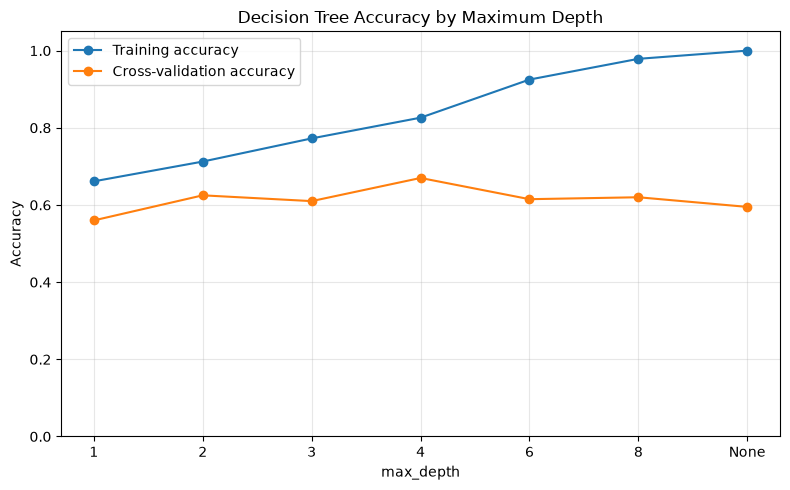

In [109]:
# TODO: tune max_depth
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

depths = [1, 2, 3, 4, 6, 8, None]
depth_results = []

for depth in depths:
    tree_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        ))
    ])

    scores = cross_validate(
        tree_pipeline,
        X_train,
        y_train,
        cv=cv,  # Same five stratified folds used earlier.
        scoring="accuracy",
        return_train_score=True
    )

    depth_results.append({
        "max_depth": str(depth),
        "Training Accuracy": scores["train_score"].mean(),
        "CV Accuracy": scores["test_score"].mean(),
        "CV Std.": scores["test_score"].std()
    })

depth_comparison = pd.DataFrame(depth_results)

print(depth_comparison.to_string(
    index=False,
    formatters={
        "Training Accuracy": "{:.2%}".format,
        "CV Accuracy": "{:.2%}".format,
        "CV Std.": "{:.2%}".format
    }
))

import matplotlib.pyplot as plt

# Use equally spaced positions so unlimited depth can be labeled "None".
positions = range(len(depth_comparison))

plt.figure(figsize=(8, 5))

plt.plot(
    positions,
    depth_comparison["Training Accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    positions,
    depth_comparison["CV Accuracy"],
    marker="o",
    label="Cross-validation accuracy"
)

plt.xticks(positions, depth_comparison["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy by Maximum Depth")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

1. What happens to training accuracy as max_depth increases?
- Training accuracy continues to increase

2. What happens to cross-validation accuracy?
- It seems to dip down before eventually plateauing

3. At what depth does the tree appear to perform best on unseen data?
- Around max_depth 4

4. Do you see evidence of underfitting?
- Not really

5. Do you see evidence of overfitting?
- Yes, CV accuracy is much lower than training accuracy



1. Which Decision Tree depth appears to underfit?
- Near depths 1-2

2. Which depth appear to generalize best?
- About depth 3

3. Do the deepest trees show signs of overfitting?
- Yes

4. Why should we not simply choose the tree with the highest training accuracy
- Because it wouldn't give us any information regarding the generalization of the accuracy because the difference between training and validation accuracy is too large

I am picking Depth 3 because there were the least signs of over and underfitting at this depth and CV and training accuracy seem to perform near the same level

In [110]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Original Decision Tree": DecisionTreeClassifier(random_state=42),
    "Tuned Decision Tree (depth=3)": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model_pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model))
    ])

    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,  # Same five stratified folds.
        scoring=scoring  # Accuracy, precision, and recall defined earlier.
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean()
    })

comparison = pd.DataFrame(results).sort_values(
    "Mean Accuracy",
    ascending=False
).reset_index(drop=True)

metric_columns = [
    "Mean Accuracy",
    "Accuracy Std",
    "Mean Precision",
    "Mean Recall"
]

print(comparison.to_string(
    index=False,
    formatters={
        column: "{:.2%}".format for column in metric_columns
    }
))

                        Model Mean Accuracy Accuracy Std Mean Precision Mean Recall
          Logistic Regression        74.00%        6.44%         72.80%      57.08%
                Random Forest        69.00%        8.46%         63.55%      53.17%
Tuned Decision Tree (depth=3)        61.00%        5.15%         52.11%      50.92%
                     Baseline        60.50%        1.00%          0.00%       0.00%
       Original Decision Tree        59.50%        6.00%         47.67%      50.92%


## 8. Final test evaluation
Choose one workflow, fit on full training data, and evaluate once on the test set.


In [111]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Fit preprocessing and Logistic Regression on the full training set.
final_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000))
])

final_model.fit(X_train, y_train)

# Generate the final test predictions.
y_pred = final_model.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(
    f"Precision (Yes): "
    f"{precision_score(y_test, y_pred, pos_label='Yes', zero_division=0):.2%}"
)
print(
    f"Recall (Yes): "
    f"{recall_score(y_test, y_pred, pos_label='Yes', zero_division=0):.2%}"
)

confusion_table = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=["No", "Yes"]),
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("\nConfusion Matrix:")
print(confusion_table)

# Choose the majority class using training data only.
final_baseline = DummyClassifier(strategy="most_frequent")
final_baseline.fit(X_train, y_train)
baseline_pred = final_baseline.predict(X_test)

print(
    f"\nMajority-Class Test Accuracy: "
    f"{accuracy_score(y_test, baseline_pred):.2%}"
)

Test Accuracy: 84.00%
Precision (Yes): 87.50%
Recall (Yes): 70.00%

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No             28              2
Actual Yes             6             14

Majority-Class Test Accuracy: 60.00%


1. How does final test accuracy compare with mean CV accuracy?
- There's is about a 20% difference

2. Is it reasonably consistent with what you observed during cross-validation?
- It is about the same

3. Did the model outperform the majority-class baseline?
- It actually underperformed a bit

4. Are precision and recall similar to the CV results?
- Yes except for the recall

## 9. Error analysis
Classification: false positives/false negatives. Regression: largest residuals.

In [112]:
# TODO: error analysis
# Reuse predictions from the final evaluation.
error_details = X_test.copy()
error_details["Actual Class"] = y_test.to_numpy()
error_details["Predicted Class"] = y_pred

# False positives: predicted Yes, but actually No.
false_positives = error_details[
    (error_details["Actual Class"] == "No") &
    (error_details["Predicted Class"] == "Yes")
]

# False negatives: predicted No, but actually Yes.
false_negatives = error_details[
    (error_details["Actual Class"] == "Yes") &
    (error_details["Predicted Class"] == "No")
]

print(f"False positives: {len(false_positives)}")
display(false_positives.head(5))

print(f"False negatives: {len(false_negatives)}")
display(false_negatives.head(5))

False positives: 2


,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,Actual Class,Predicted Class
132,9.7,5.7,92.9,13,Some,Yes,0,No,Yes
169,9.4,7.5,98.3,19,None,No,45,No,Yes


False negatives: 6


,study_hours_per_week,sleep_hours_per_night,attendance_rate,practice_problems_per_week,prior_programming_experience,study_group,commute_minutes,Actual Class,Predicted Class
113,10.3,6.0,89.5,9,Some,No,38,Yes,No
80,5.6,7.6,87.3,36,None,No,28,Yes,No
140,9.4,7.0,82.8,13,Some,No,31,Yes,No
37,5.5,7.1,78.3,22,Some,Yes,19,Yes,No
89,NaN,6.2,72.7,15,Strong,No,28,Yes,No


1. How many false positive occured?
- 2

2. How many false negatives occured?
- 6

3. Do you notice any patterns among the mistakes?
- Sleep hour patterns range from 5-8

4. Are some observations likely more difficult to clasify than others?
- The model could've made these mistakes because of how generic some of the data is to the point where the models can't properly classify the correct class

Try Logistic Regression
        ↓
check TEST accuracy
        ↓
Try Decision Tree
        ↓
check TEST accuracy
        ↓
Change max_depth
        ↓
check TEST accuracy
        ↓
Change max_depth again
        ↓
check TEST accuracy
        ↓
Choose the highest test result

1. What is wrong with this procedure?
- We're using test set to select the model and tune hyperparameters, making it no longer a independent final evaluation

2. How has the test set indirectly become part of model developement?
- We are now testing the model on how well it performs on already seen data, which will boost accuracy unnaturally

3. Why is the final test score no longer a completely independent evaluation?
- It is because the model already knows the answer to most of the testing set data because it's something it has seen before

1. Why is scaling useful for Logistic Regression?
- Scaling puts numerical features on comparable scales, helping optimization process converge efficiently. It also makes regularization more consistent across features measured in different units

2. Why do Decision Trees generally not require scaling?
- Trees split data using thresholds such as attendance rate < 85. Scaling changes the threshold's numerical value but preserves the ordering of observations, so the same split remains possible

3. Why do Random Forests generally not require scaling?
- Random forest combines many Decision trees, since Decision trees don't require scaling, neither does Random forest

I expect Logistic Regression with scaling to achieve slightly higher mean cross-validation accuracy because scaling makes regularization more consistent across numerical features.

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score, pos_label="Yes", zero_division=0
    ),
    "recall": make_scorer(
        recall_score, pos_label="Yes", zero_division=0
    )
}

# Freeze the same five folds for both pipelines.
folds = list(cv.split(X_train, y_train))

scaling_results = []
accuracy_by_model = {}

for name, use_scaling in [("Scaled", True), ("Unscaled", False)]:
    numeric_steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]
    if use_scaling:
        numeric_steps.append(("scaler", StandardScaler()))

    experiment_preprocessor = ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ])

    experiment_pipeline = Pipeline([
        ("preprocessor", experiment_preprocessor),
        ("model", LogisticRegression(max_iter=5000))
    ])

    scores = cross_validate(
        experiment_pipeline,
        X_train,
        y_train,
        cv=folds,
        scoring=scoring
    )

    accuracy_by_model[name] = scores["test_accuracy"]

    scaling_results.append({
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean()
    })

scaling_comparison = pd.DataFrame(scaling_results)

print(scaling_comparison.to_string(
    index=False,
    formatters={
        column: "{:.2%}".format
        for column in scaling_comparison.columns
        if column != "Model"
    }
))

# Compare accuracy differences within matching validation folds.
fold_differences = (
    accuracy_by_model["Scaled"] - accuracy_by_model["Unscaled"]
)

print(
    f"\nMean accuracy difference (scaled − unscaled): "
    f"{fold_differences.mean() * 100:.2f} percentage points"
)
print(
    f"Std. of fold accuracy differences: "
    f"{fold_differences.std() * 100:.2f} percentage points"
)

   Model Mean CV Accuracy CV Accuracy Std Mean Precision Mean Recall
  Scaled           74.00%           6.44%         72.80%      57.08%
Unscaled           74.50%           6.40%         73.25%      58.33%

Mean accuracy difference (scaled − unscaled): -0.50 percentage points
Std. of fold accuracy differences: 1.00 percentage points


Since the scaled Mean CV accuracy is lowered than the unscaled version, the results do not support my hypothesis

## 10. Conclusion and AI Reflection
Summarize your evidence. Describe one AI suggestion you rejected or modified and why.

I asked AI to explain five-fold cross-validation. It recommended comparing models using only the training data and saving the test set for final evaluation. I followed this advice and verified that my code used X_train and y_train. I kept the comparison limited to the required models. I learned that cross-validation supports model selection, while the test set provides an independent final assessment. AI did not recommend tuning with the test set.